# Host-Level Classification
**Multi-class conformal prediction for bacteriophage host-genus prediction**

We build one conformal envelope trained on true-label NC score vectors using the CSA two-stage calibration procedure.

**Data source:** `random_pc_r_5_da_2_bal_s_{0..4}/` — five split folders, each containing clean per-fold predictions.  
  - Fold 0 proteins → **test set**
  - Folds 1–4 proteins → **training / calibration set**

- No contamination masking is needed: the folder structure already encodes which proteins are clean for each fold.


- For each test phage and each host hypothesis `h`, we compute:
    - NC_h = 1 − score_h  (low score for true host = high nonconformity = surprising)

The prediction set includes all hosts `h` for which NC_h ≤ t̂ × q̃.

In [1]:
import os
import sys
import pickle
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# numpy compatibility shim (needed on some cluster environments)
import numpy
sys.modules['numpy._core'] = numpy.core
warnings.filterwarnings("ignore")

### Data

In [2]:
METADATA_PATH = Path("../Data/metadata.csv")

SPLIT_DIRS = {i: Path(f"../Data/random_pc_r_5_da_2_bal_s_{i}") for i in range(5)}

for i, d in SPLIT_DIRS.items():
    status = "OK" if d.exists() else "MISSING"
    print(f"  Split {i}: {d.name}  [{status}]")

# Loading metadata 
print("\nLoading metadata...")
meta_df = pd.read_csv(METADATA_PATH, index_col="proteinID")
print(f"  metadata shape : {meta_df.shape}")

alpha = 0.1

  Split 0: random_pc_r_5_da_2_bal_s_0  [OK]
  Split 1: random_pc_r_5_da_2_bal_s_1  [OK]
  Split 2: random_pc_r_5_da_2_bal_s_2  [OK]
  Split 3: random_pc_r_5_da_2_bal_s_3  [OK]
  Split 4: random_pc_r_5_da_2_bal_s_4  [OK]

Loading metadata...
  metadata shape : (1853074, 8)


#### Discovering functions and host labels

In [3]:
gram_types = ["gramneg", "grampos"]

# Discovering function names from split-0 grampos files
sample_files = sorted(SPLIT_DIRS[0].glob("all_preds_grampos_*.pkl"))
functions = sorted([f.stem.replace("all_preds_grampos_", "") for f in sample_files])
print(f"Found {len(functions)} protein functions:")
print("  " + ", ".join(functions))

# Discovering host labels from one reference file per gram type
ref_gramneg = pd.read_pickle(SPLIT_DIRS[0] / f"all_preds_gramneg_{functions[0]}.pkl")
ref_grampos = pd.read_pickle(SPLIT_DIRS[0] / f"all_preds_grampos_{functions[0]}.pkl")
hosts_gramneg = [c.replace(f"_{functions[0]}", "") for c in ref_gramneg.columns]
hosts_grampos = [c.replace(f"_{functions[0]}", "") for c in ref_grampos.columns]
all_hosts = sorted(set(hosts_gramneg + hosts_grampos))

print(f"\\nGram-negative hosts ({len(hosts_gramneg)}): {hosts_gramneg}")
print(f"\\nGram-positive hosts ({len(hosts_grampos)}): {hosts_grampos}")
print(f"\\nAll hosts combined ({len(all_hosts)}): {all_hosts}")

Found 40 protein functions:
  DNA-associated, DNA_polymerase, RNA-associated, adsorption-related, annealing, anti-restriction, baseplate, capsid, cell_wall_depolymerase, ejection, endolysin, head-tail_joining, helicase, holin, integration, lysin, lysis, lysis_inhibitor, nuclease, nucleotide_metabolism, packaging_assembly, phosphorylation, portal, primase, pvp, reductase, replication_initiation, sir2, spanin, super_infection, tail, tail_appendage, tail_sheath, terminase, toxin, transcriptional_activator, transcriptional_regulator, transcriptional_repressor, transferase, val
\nGram-negative hosts (38): ['Xanthomonas', 'Edwardsiella', 'Pseudoalteromonas', 'Roseobacter', 'Halorubrum', 'Synechococcus', 'Sulfolobus', 'Sinorhizobium', 'Shigella', 'Yersinia', 'Flavobacterium', 'Prochlorococcus', 'Haloarcula', 'Erwinia', 'Proteus', 'Citrobacter', 'Rhizobium', 'Stenotrophomonas', 'Campylobacter', 'Pantoea', 'Enterobacter', 'Caulobacter', 'Dickeya', 'Cronobacter', 'Cellulophaga', 'Rhodobacter', '

In [4]:
# Comparing host sets between Gram types
set_neg = set(hosts_gramneg)
set_pos = set(hosts_grampos)

shared_hosts = sorted(set_neg.intersection(set_pos))
only_neg = sorted(set_neg - set_pos)
only_pos = sorted(set_pos - set_neg)


print(f"Hosts present in BOTH Gram types ({len(shared_hosts)}):")
print(f"  {shared_hosts}")
print(f"\nHosts unique to Gram-negative ONLY ({len(only_neg)}):")
print(f"  {only_neg}")
print(f"\nHosts unique to Gram-positive ONLY ({len(only_pos)}):")
print(f"  {only_pos}")

Hosts present in BOTH Gram types (0):
  []

Hosts unique to Gram-negative ONLY (38):
  ['Campylobacter', 'Caulobacter', 'Cellulophaga', 'Citrobacter', 'Cronobacter', 'Dickeya', 'Edwardsiella', 'Enterobacter', 'Erwinia', 'Escherichia', 'Flavobacterium', 'Haloarcula', 'Halorubrum', 'Klebsiella', 'Microcystis', 'Pantoea', 'Pectobacterium', 'Pelagibacter', 'Prochlorococcus', 'Proteus', 'Providencia', 'Pseudoalteromonas', 'Pseudomonas', 'Ralstonia', 'Rhizobium', 'Rhodobacter', 'Roseobacter', 'Salmonella', 'Serratia', 'Shewanella', 'Shigella', 'Sinorhizobium', 'Stenotrophomonas', 'Sulfolobus', 'Synechococcus', 'Vibrio', 'Xanthomonas', 'Yersinia']

Hosts unique to Gram-positive ONLY (16):
  ['Clostridioides', 'Clostridium', 'Corynebacterium', 'Enterococcus', 'Gordonia', 'Lacticaseibacillus', 'Lactobacillus', 'Lactococcus', 'Listeria', 'Microbacterium', 'Mycobacterium', 'Paenibacillus', 'Propionibacterium', 'Staphylococcus', 'Streptococcus', 'Streptomyces']


### Protein-to-Phage Aggregation
Each phage has multiple proteins. We aggregate protein-level scores to phage level using NaN-aware mean pooling. Proteins with no score for a given (host, function) column contribute NaN

**Loading and Assembling the Score Matrix**
For each function and gram type, we load prediction files from each split folder and concatenate. The result is a protein-indexed dataframe with columns `{Host}_{function}` — one score per protein per (host, function) pair.

- **Training proteins**: folds 1–4 (concatenated from `_s_1` … `_s_4`)  
- **Test proteins**: fold 0 (from `_s_0`)

In [5]:
import gc 

print("Assembling PHAGE-level score matrix cleanly...")
t0 = time.time()

# 1. Pre-align your metadata index for lightning-fast matching inside the loops
# We only pull what we need: accession maps proteins to phages, split tells us the fold
meta_lookup = meta_df[["accession", "split"]]

# Containers to hold localized phage-level frames
train_phage_frames = []
test_phage_frames = []

for gram in gram_types:
    for func in functions:
        # Loop through splits 0 to 4 cleanly
        for s in range(5):
            p = SPLIT_DIRS[s] / f"all_preds_{gram}_{func}.pkl"
            if not p.exists():
                continue
                
            # Load the individual file (downcasted to save intermediate RAM)
            prot_df = pd.read_pickle(p).astype(np.float32)
            
            # Instantly join with metadata to separate train/test fractions
            # This drops rows that don't belong to this cross-validation block
            combined = prot_df.join(meta_lookup, how="inner")
            
            if s == 0:
                # --- TEST SET DATA ---
                # Keep only what genuinely belongs to fold 0
                test_subset = combined[combined["split"] == 0]
                if not test_subset.empty:
                    # Compress from 1.3M proteins down to a few thousand phages immediately!
                    phage_test = test_subset.groupby("accession")[prot_df.columns].mean()
                    test_phage_frames.append(phage_test)
            else:
                # --- TRAINING SET DATA (Splits 1, 2, 3, 4) ---
                # Keep only proteins matching their active training assignment
                train_subset = combined[combined["split"] == s]
                if not train_subset.empty:
                    # Compress from proteins to phages immediately!
                    phage_train = train_subset.groupby("accession")[prot_df.columns].mean()
                    train_phage_frames.append(phage_train)
                    
            # Aggressively clear intermediate memory fragments
            del prot_df, combined
            
        gc.collect()

print("Merging columns at the PHAGE level...")
# 2. Combine your files column-wise. Because they are grouped by phage, 
# this deals with thousands of rows instead of millions.
# Outer join automatically inserts NaNs for missing combinations, matching your exact logic!
train_phage_scores = pd.concat(train_phage_frames, axis=1)
test_phage_scores  = pd.concat(test_phage_frames, axis=1)

# Average out duplicate columns if a host/function matches across different frames
# Transpose, group by columns (now rows), take mean, and transpose back
train_phage_scores = train_phage_scores.T.groupby(level=0).mean().T
test_phage_scores  = test_phage_scores.T.groupby(level=0).mean().T

# 3. Re-attach the base phage labels (host, split) from the original metadata
phage_meta = meta_df.groupby("accession")[["host", "split"]].first()

train_phage_df = train_phage_scores.join(phage_meta, how="inner")
test_phage_df  = test_phage_scores.join(phage_meta, how="inner")
train_phage_df["split"] = train_phage_df["split"].astype(int)
test_phage_df["split"]  = test_phage_df["split"].astype(int)

# Extract final score column definitions for your downstream cells
score_cols = [c for c in train_phage_scores.columns]

print(f"  Done in {time.time()-t0:.1f}s")
print(f"  Train phage matrix shape: {train_phage_df.shape} (Phages x Features)")
print(f"  Test  phage matrix shape: {test_phage_df.shape} (Phages x Features)")

Assembling PHAGE-level score matrix cleanly...
Merging columns at the PHAGE level...
  Done in 103.3s
  Train phage matrix shape: (14021, 2038) (Phages x Features)
  Test  phage matrix shape: (4422, 2038) (Phages x Features)


In [6]:
### Loading Metadata"))
print("Loading metadata ...")
t0 = time.time()
meta_df = pd.read_csv(METADATA_PATH, index_col="proteinID")
meta_df = meta_df[["accession", "host", "host_type", "split"]]
print(f"  metadata shape: {meta_df.shape}  ({time.time()-t0:.1f}s)")
print(meta_df.head(5))
print("\nUnique hosts in metadata:", meta_df["host"].nunique())
print("\nHost value counts (top 10):")
print(meta_df["host"].value_counts().head(10))

Loading metadata ...
  metadata shape: (1853074, 4)  (3.2s)
               accession    host host_type  split
proteinID                                        
AB002632_00001  AB002632  Vibrio  gram-neg      0
AB002632_00002  AB002632  Vibrio  gram-neg      0
AB002632_00003  AB002632  Vibrio  gram-neg      0
AB002632_00004  AB002632  Vibrio  gram-neg      0
AB002632_00005  AB002632  Vibrio  gram-neg      0

Unique hosts in metadata: 304

Host value counts (top 10):
host
Escherichia       244599
Mycobacterium     242469
Salmonella        105784
Pseudomonas        98825
Vibrio             97494
Klebsiella         97015
Synechococcus      81953
Staphylococcus     79162
Bacillus           68215
Gordonia           57268
Name: count, dtype: int64


In [7]:
phage_level_meta = meta_df.groupby("accession")[["host", "host_type"]].first()

print("Phage counts per host (top 10):")
print(phage_level_meta["host"].value_counts().head(10))
print(phage_level_meta["host"].value_counts())

Phage counts per host (top 10):
host
Mycobacterium     2352
Escherichia       2254
Pseudomonas       1023
Klebsiella         966
Salmonella         958
Vibrio             917
Streptococcus      740
Gordonia           657
Staphylococcus     652
Microbacterium     545
Name: count, dtype: int64
host
Mycobacterium       2352
Escherichia         2254
Pseudomonas         1023
Klebsiella           966
Salmonella           958
                    ... 
Polaromonas            1
Alicyclobacillus       1
Mycobacteroides        1
Macromonas             1
Acholeplasma           1
Name: count, Length: 304, dtype: int64


### Filter to Known Hosts Only
We keep only phages whose true host genus appears in our score columns. Phages with `host = unknown` or a genus not covered by the model are excluded.

we saw that our model has seen 54 different hosts while the data has 304 different so filtering out the uncommon ones

In [8]:
# Extract the set of host present as score columns
# Score columns are {Host}_{function} — extract unique host names
scored_hosts = set()
for col in score_cols:
    for func in functions:
        if col.endswith("_" + func):
            host_name = col[: -(len(func) + 1)]
            scored_hosts.add(host_name)
            break
print(f"Hosts covered by score columns ({len(scored_hosts)}): {sorted(scored_hosts)}")

# Keep only phages whose true host is in scored_hosts
train_phage_df = train_phage_df[train_phage_df["host"].isin(scored_hosts)].copy()
test_phage_df = test_phage_df[test_phage_df["host"].isin(scored_hosts)].copy()

print(f"\\nAfter filtering:")
print(f"  Train phages: {len(train_phage_df)}")
print(f"  Test  phages: {len(test_phage_df)}")
print("\\nTrain host distribution:")
print(train_phage_df["host"].value_counts())

Hosts covered by score columns (54): ['Campylobacter', 'Caulobacter', 'Cellulophaga', 'Citrobacter', 'Clostridioides', 'Clostridium', 'Corynebacterium', 'Cronobacter', 'Dickeya', 'Edwardsiella', 'Enterobacter', 'Enterococcus', 'Erwinia', 'Escherichia', 'Flavobacterium', 'Gordonia', 'Haloarcula', 'Halorubrum', 'Klebsiella', 'Lacticaseibacillus', 'Lactobacillus', 'Lactococcus', 'Listeria', 'Microbacterium', 'Microcystis', 'Mycobacterium', 'Paenibacillus', 'Pantoea', 'Pectobacterium', 'Pelagibacter', 'Prochlorococcus', 'Propionibacterium', 'Proteus', 'Providencia', 'Pseudoalteromonas', 'Pseudomonas', 'Ralstonia', 'Rhizobium', 'Rhodobacter', 'Roseobacter', 'Salmonella', 'Serratia', 'Shewanella', 'Shigella', 'Sinorhizobium', 'Staphylococcus', 'Stenotrophomonas', 'Streptococcus', 'Streptomyces', 'Sulfolobus', 'Synechococcus', 'Vibrio', 'Xanthomonas', 'Yersinia']
\nAfter filtering:
  Train phages: 11694
  Test  phages: 3944
\nTrain host distribution:
host
Mycobacterium         1855
Escherichi

### Build Per-Host Score Vectors
For each phage and each candidate host `h`, we aggregate across all function columns for that host:

$$\text{score}(\text{phage}, h) = \frac{1}{|F_h|} \sum_{f \in F_h} \text{mean\_protein\_score}_{h,f}$$

This gives a `(n_phages, n_hosts)` matrix — the core input to conformal prediction.

The transformation is:  
$$\text{NC}(\text{phage}, h) = 1 - \text{score}(\text{phage}, h)$$

Low score for the true host → high NC → the phage is poorly explained by that host.

In [9]:
sorted_hosts = sorted(scored_hosts)
H = len(sorted_hosts)

def build_host_score_matrix(phage_df, host_list, score_cols, functions):
    """
    For each phage, compute one aggregated score per host by averaging
    across all function columns for that host.
    Returns array of shape (n_phages, n_hosts).
    """
    n = len(phage_df)
    mat = np.full((n, len(host_list)), np.nan)
    for j, host in enumerate(host_list):
        host_cols = [c for c in score_cols if c.startswith(host + "_")]
        if not host_cols:
            continue
        mat[:, j] = phage_df[host_cols].mean(axis=1).values
    return mat

print("Building host score matrices ...")
t0 = time.time()
train_raw_full = build_host_score_matrix(train_phage_df, sorted_hosts, score_cols, functions)
test_raw_full  = build_host_score_matrix(test_phage_df,  sorted_hosts, score_cols, functions)
print(f"  Done in {time.time()-t0:.1f}s")
print(f"  Train host score matrix: {train_raw_full.shape}  (phages x hosts)")
print(f"  Test  host score matrix: {test_raw_full.shape}")

train_labels = train_phage_df["host"].to_numpy(dtype=str)
test_labels  = test_phage_df["host"].to_numpy(dtype=str)

Building host score matrices ...
  Done in 0.3s
  Train host score matrix: (11694, 54)  (phages x hosts)
  Test  host score matrix: (3944, 54)


### Median Imputation
After aggregation, some phage-host cells remain NaN because none of the phage's proteins had annotations for any function used by that host's model.

We impute using **global training medians** — the same values applied to both train and test to preserve exchangeability.

In [10]:
# Compute global column medians from training set only
train_medians = np.nanmedian(train_raw_full, axis=0)   # shape (H,)

# Cap at 0.6 → 0.5 to avoid imputing artificially high host affinity
safe_medians = np.where(train_medians > 0.6, 0.5, train_medians)

# Apply to both train and test
def impute(mat, medians):
    out = mat.copy()
    nan_mask = np.isnan(out)
    out[nan_mask] = np.take(medians, np.where(nan_mask)[1])
    return out

train_raw = impute(train_raw_full, safe_medians)
test_raw = impute(test_raw_full,  safe_medians)

# Final fallback for any host column with no training data at all
train_raw = np.nan_to_num(train_raw, nan=0.5)
test_raw = np.nan_to_num(test_raw,  nan=0.5)

nan_frac_train = np.isnan(train_raw_full).mean()
nan_frac_test  = np.isnan(test_raw_full).mean()
print(f"NaN fraction before imputation — train: {nan_frac_train:.3f}, test: {nan_frac_test:.3f}")
print(f"NaN fraction after  imputation — train: {np.isnan(train_raw).mean():.3f}, test: {np.isnan(test_raw).mean():.3f}")

print("\nImputed medians (first 5 hosts):")
for h, m, sm in zip(sorted_hosts[:5], train_medians[:5], safe_medians[:5]):
    print(f"  {h}: raw_median={m:.4f}, safe_impute={sm:.4f}")

NaN fraction before imputation — train: 0.473, test: 0.445
NaN fraction after  imputation — train: 0.000, test: 0.000

Imputed medians (first 5 hosts):
  Campylobacter: raw_median=0.0105, safe_impute=0.0105
  Caulobacter: raw_median=0.0139, safe_impute=0.0139
  Cellulophaga: raw_median=0.0100, safe_impute=0.0100
  Citrobacter: raw_median=0.0311, safe_impute=0.0311
  Clostridioides: raw_median=0.0018, safe_impute=0.0018


### Score Verification

In [11]:
print("Mean host score per phage (averaged across all host columns):")
host_to_idx = {h: i for i, h in enumerate(sorted_hosts)}
for host in sorted_hosts:
    mask = train_labels == host
    if mask.sum() == 0:
        continue
    j = host_to_idx[host]
    mean_self = train_raw[mask, j].mean()   # score for own (true) host
    mean_other = np.delete(train_raw[mask], j, axis=1).mean()  # score for other hosts
    print(f"  {host:25s}: self_score={mean_self:.3f}  other_mean={mean_other:.3f}  n={mask.sum()}")

Mean host score per phage (averaged across all host columns):
  Campylobacter            : self_score=0.667  other_mean=0.035  n=96
  Caulobacter              : self_score=0.695  other_mean=0.035  n=31
  Cellulophaga             : self_score=0.747  other_mean=0.032  n=45
  Citrobacter              : self_score=0.483  other_mean=0.053  n=39
  Clostridioides           : self_score=0.777  other_mean=0.040  n=17
  Clostridium              : self_score=0.811  other_mean=0.032  n=90
  Corynebacterium          : self_score=0.779  other_mean=0.029  n=27
  Cronobacter              : self_score=0.512  other_mean=0.043  n=32
  Dickeya                  : self_score=0.629  other_mean=0.047  n=34
  Edwardsiella             : self_score=0.553  other_mean=0.039  n=8
  Enterobacter             : self_score=0.477  other_mean=0.049  n=57
  Enterococcus             : self_score=0.764  other_mean=0.026  n=164
  Erwinia                  : self_score=0.628  other_mean=0.037  n=128
  Escherichia              

### True-Label Transformation
For a phage with true host `h*`, the NC vector is:
$$\text{NC}_j = 1 - \text{score}_j \quad \forall j$$

But we **only use the true-label NC vector during envelope training** — the NC value at position `h*`. Specifically, for S1 shape discovery, each phage contributes a scalar: `NC_{h*} = 1 - score_{h*}`.

At test time, we generate one candidate NC score per host hypothesis and check each against the envelope.

In [12]:
def get_true_label_nc(raw_scores, labels, host_list):
    """
    For each phage, extract the score value for its true host.
    transformed score = 1 - score_{true_host}
    Returns 1D array of shape (n_phages,).
    """
    host_to_idx = {h: i for i, h in enumerate(host_list)}
    nc = np.array([
        1.0 - raw_scores[i, host_to_idx[labels[i]]]
        for i in range(len(labels))
        if labels[i] in host_to_idx
    ])
    return nc

nc_train_true = get_true_label_nc(train_raw, train_labels, sorted_hosts)
print(f"True-label scores (train): mean={nc_train_true.mean():.3f}, std={nc_train_true.std():.3f}")
print(f"  Low scores (well predicted): {(nc_train_true < 0.3).mean()*100:.1f}% of phages")
print(f"  High scores (poorly predicted): {(nc_train_true > 0.7).mean()*100:.1f}% of phages")

True-label scores (train): mean=0.242, std=0.140
  Low scores (well predicted): 73.3% of phages
  High scores (poorly predicted): 1.4% of phages


### S1 / S2 Split
The training set is shuffled and split 50/50:
- **S1** (Shape Discovery): used to learn the geometry of the conformal envelope
- **S2** (Size Scaling): used to calibrate t̂ so the envelope achieves target coverage

Shuffling before splitting ensures both classes are well represented in S2.

In [13]:
train_shuffled_idx = np.random.default_rng(42).permutation(len(train_raw))
half = len(train_shuffled_idx) // 2
s1_idx = train_shuffled_idx[:half]
s2_idx = train_shuffled_idx[half:]

s1_raw = train_raw[s1_idx]
s2_raw = train_raw[s2_idx]
labels_S1 = train_labels[s1_idx]
labels_S2 = train_labels[s2_idx]

print(f"S1 (shape discovery): {s1_raw.shape}")
print(f"S2 (size scaling):    {s2_raw.shape}")
print("\\nHost distribution in S2 (top 10):")
s2_counts = pd.Series(labels_S2).value_counts()
print(s2_counts.head(10))
min_count = s2_counts.min()
print(f"\\nSmallest class in S2: {s2_counts.idxmin()} — {min_count} phages")
if min_count < 5:
    print("  WARNING: very few S2 phages for this host — quantile will be unreliable")

S1 (shape discovery): (5847, 54)
S2 (size scaling):    (5847, 54)
\nHost distribution in S2 (top 10):
Mycobacterium     943
Escherichia       695
Salmonella        406
Klebsiella        406
Pseudomonas       406
Vibrio            333
Streptococcus     290
Gordonia          279
Staphylococcus    214
Microbacterium    208
Name: count, dtype: int64
\nSmallest class in S2: Microcystis — 2 phages


#### COnstructing the envelope

In [14]:
def quantile_for_class(tau_scores, labels, cls, alpha):
    """
    Compute the conformal quantile for a single class.
    Returns the ceiling((n+1)(1-alpha))-th smallest tau score.
    """
    vals = np.sort(tau_scores[labels == cls])
    n = len(vals)
    if n == 0:
        return 0.0
    idx = int(np.ceil((n + 1) * (1 - alpha))) - 1
    return vals[np.clip(idx, 0, n - 1)]

# def t_hat_over_all_classes(tau_scores, labels, alpha, host_list):
#     """
#     Compute per-class conformal quantile and take the maximum.
#     This guarantees coverage >= (1-alpha) for every host class.
#     Uses t_hat_per_class max strategy — guarantees the worst-covered
#     class still meets the target.
#     """
#     per_class = {
#         h: quantile_for_class(tau_scores, labels, h, alpha)
#         for h in host_list
#     }
#     t_hat = max(per_class.values())
#     worst = max(per_class, key=per_class.get)
#     print(f"    t_hat = {t_hat:.4f}  (worst class: {worst})")
#     return t_hat, per_class

def t_hat_over_all_classes(tau_scores, labels, alpha, host_list):
    # Treat all tau scores as one global pool and find the global (1 - alpha) quantile
    t_hat = np.quantile(tau_scores, 1 - alpha)
    
    # seeing how individual classes would have fared
    per_class = {
        h: quantile_for_class(tau_scores, labels, h, alpha)
        for h in host_list
    }
    
    print(f"  GLOBAL POOL t_hat = {t_hat:.4f}")
    return t_hat, per_class

#### Collapsed 1D envelope
Each H-dimensional score vector is reduced to a scalar by taking the NC score at the true host (1D projection). A single quantile threshold is calibrated on S2.

At test time, for each host hypothesis `h`, the NC score is `1 - score_h`. A phage is predicted to have host `h` if `NC_h ≤ q̃ × t̂`

In [15]:
def collapsed_build_envelope(s1_raw, s2_raw, labels_S1, labels_S2, alpha, host_list):
    """
    Build collapsed 1D conformal envelope.
    S1: learn q_tilde as the (1-alpha) quantile of true-host NC scores.
    S2: compute tau = NC_{true} / q_tilde for each phage; calibrate t_hat.
    """
    host_to_idx = {h: i for i, h in enumerate(host_list)}
    # S1: true-label NC scores
    nc_s1 = np.array([1.0 - s1_raw[i, host_to_idx[labels_S1[i]]]
                      for i in range(len(labels_S1))
                      if labels_S1[i] in host_to_idx])
    q_tilde = np.quantile(nc_s1, 1 - alpha)
    # S2: tau scores
    nc_s2 = np.array([1.0 - s2_raw[i, host_to_idx[labels_S2[i]]]
                      for i in range(len(labels_S2))
                      if labels_S2[i] in host_to_idx])
    tau_scores = nc_s2 / (q_tilde + 1e-12)
    # Use per-class t_hat to guarantee all classes covered
    labels_S2_valid = np.array([labels_S2[i] for i in range(len(labels_S2))
                                if labels_S2[i] in host_to_idx])
    t_hat, per_class = t_hat_over_all_classes(tau_scores, labels_S2_valid, alpha, host_list)
    return {"method": "collapsed", "q_tilde": q_tilde, "t_hat": t_hat,
            "t_hat_per_class": per_class}

def collapsed_predict(test_raw, envelope, host_list):
    """
    For each test phage, return the prediction set of hosts whose
    NC score is within the calibrated envelope.
    """
    threshold = envelope["q_tilde"] * envelope["t_hat"]
    results = []
    for i in range(len(test_raw)):
        pred_set = []
        for j, h in enumerate(host_list):
            nc = 1.0 - test_raw[i, j]
            if nc <= threshold:
                pred_set.append(h)
        results.append({"prediction_set": pred_set})
    return results

print("Building Collapsed 1D envelope ...")
t0 = time.time()
c_env = collapsed_build_envelope(s1_raw, s2_raw, labels_S1, labels_S2, alpha, sorted_hosts)
print(f"  Done in {time.time()-t0:.1f}s")
print(f"  q_tilde = {c_env['q_tilde']:.4f},  t_hat = {c_env['t_hat']:.4f}")

Building Collapsed 1D envelope ...
  GLOBAL POOL t_hat = 0.9858
  Done in 0.0s
  q_tilde = 0.4149,  t_hat = 0.9858


#### Radial Envelope
- Samples M random directions on the positive orthant of the unit sphere in NC space. 
- For each direction, computes the local (1-alpha) quantile of NC magnitudes from S1 points 
- within 30° of that direction. At test time, a point is inside the envelope if it falls within at least one scaled sector.

In [16]:
def sample_positive_sphere(M, K, seed=0):
    rng = np.random.default_rng(seed)
    V = np.abs(rng.standard_normal((M, K)))
    return V / (np.linalg.norm(V, axis=1, keepdims=True) + 1e-12)

def radial_build_envelope(s1_raw, s2_raw, labels_S1, labels_S2, alpha, host_list, 
                           M=200, delta_deg=30):
    K = len(host_list)
    U = sample_positive_sphere(M, K)
    # S1: true-label NC vectors — for host classification NC_j = 1 - score_j
    # Shape discovery uses the FULL NC vector (all hosts) of each S1 phage
    S1_nc = 1.0 - s1_raw   # (n_s1, K)
    mags  = np.linalg.norm(S1_nc, axis=1)
    dirs  = S1_nc / (mags[:, None] + 1e-12)
    cos_thresh = np.cos(np.radians(delta_deg))
    q_tilde = np.array([
        np.quantile(mags[(dirs @ U[m]) >= cos_thresh], 1 - alpha)
        if ((dirs @ U[m]) >= cos_thresh).sum() > 5
        else np.quantile(mags, 1 - alpha)
        for m in range(M)
    ])

    # S2: tau scores
    S2_nc = 1.0 - s2_raw   # (n_s2, K)
    # tau_i = min over m of max_k( S2_nc[i,k] / (U[m,k] * q_tilde[m]) )
    tau_scores = (
        (S2_nc[:, None, :] / (U * q_tilde[:, None])[None, :, :])
        .max(axis=2).min(axis=1)
    )
    labels_S2_valid = labels_S2   # all should be valid after earlier filter
    t_hat, per_class = t_hat_over_all_classes(tau_scores, labels_S2_valid, alpha, host_list)
    return {"method": "radial", "U": U, "q_tilde": q_tilde,
            "t_hat": t_hat, "t_hat_per_class": per_class}

def radial_predict(test_raw, envelope, host_list):
    U, q_tilde, t_hat = envelope["U"], envelope["q_tilde"], envelope["t_hat"]
    results = []
    for i in range(len(test_raw)):
        pred_set = []
        for j, h in enumerate(host_list):
            # Evaluate the scalar radial check for host h
            nc_h = 1.0 - test_raw[i, j]
            if nc_h <= q_tilde.mean() * t_hat:
                pred_set.append(h)
        results.append({"prediction_set": pred_set})
    return results

print("\nBuilding Radial envelope ...")
t0 = time.time()
r_env = radial_build_envelope(s1_raw, s2_raw, labels_S1, labels_S2, alpha, sorted_hosts, M=200)
print(f"  Done in {time.time()-t0:.1f}s")
print(f"  t_hat = {r_env['t_hat']:.4f}")


Building Radial envelope ...
  GLOBAL POOL t_hat = 8.7938
  Done in 0.2s
  t_hat = 8.7938


### Strip Envelope 
- Slices NC space into bins along each host dimension and captures correlations between dimensions. Given the high dimensionality (H hosts), M=10 bins is used to keep memory manageable.
- With H=35 dimensions, the strip envelope is O(H²×M) in memory. For large H this is the most memory-intensive method.


In [17]:
def strip_build_envelope(s1_raw, s2_raw, labels_S1, labels_S2, alpha, host_list, M=10):
    S1_nc = 1.0 - s1_raw
    S2_nc = 1.0 - s2_raw
    K = S1_nc.shape[1]
    bin_edges = np.array([np.linspace(S1_nc[:, j].min(), S1_nc[:, j].max(), M + 1) for j in range(K)])
    limits = np.zeros((K, K, M))
    for j in range(K):
        for m in range(M):
            lo, hi = bin_edges[j, m], bin_edges[j, m + 1]
            in_strip = (S1_nc[:, j] >= lo) & (S1_nc[:, j] < hi)
            for i in range(K):
                if i == j:
                    continue
                src = S1_nc[in_strip, i] if in_strip.sum() >= 3 else S1_nc[:, i]
                limits[j, i, m] = np.quantile(src, 1 - alpha)

    # Monotonicity propagation
    for j in range(K):
        for i in range(K):
            if i == j:
                continue
            for m in range(M - 2, -1, -1):
                limits[j, i, m] = max(limits[j, i, m], limits[j, i, m + 1])

    # S2 tau scores
    def get_tau(nc_mat):
        N, K_ = nc_mat.shape
        M_ = bin_edges.shape[1] - 1
        bin_idx = np.array([
            np.clip(np.digitize(nc_mat[:, j], bin_edges[j]) - 1, 0, M_ - 1) for j in range(K_)]).T
        ratios = np.zeros((N, K_, K_))
        for j in range(K_):
            for i in range(K_):
                if i == j:
                    continue
                lims = limits[j, i, bin_idx[:, j]]
                ratios[:, j, i] = nc_mat[:, i] / (lims + 1e-12)
        return ratios.max(axis=(1, 2))

    tau_scores = get_tau(S2_nc)
    t_hat, per_class = t_hat_over_all_classes(tau_scores, labels_S2, alpha, host_list)
    return {"method": "strip", "bin_edges": bin_edges, "limits": limits,
            "t_hat": t_hat, "t_hat_per_class": per_class, "_get_tau": get_tau}

def strip_predict(test_raw, envelope, host_list):
    bin_edges = envelope["bin_edges"]
    limits = envelope["limits"]
    t_hat = envelope["t_hat"]
    K = len(host_list)
    M = bin_edges.shape[1] - 1
    test_nc = 1.0 - test_raw
    N = len(test_raw)
    bin_idx = np.array([
        np.clip(np.digitize(test_nc[:, j], bin_edges[j]) - 1, 0, M - 1)
        for j in range(K)
    ]).T
    results = []
    for i in range(N):
        pred_set = []
        for j_h, h in enumerate(host_list):
            nc_h = test_nc[i, j_h]
            ok = True
            for j2 in range(K):
                if j2 == j_h:
                    continue
                lim = limits[j2, j_h, bin_idx[i, j2]]
                if nc_h > lim * t_hat:
                    ok = False
                    break
            if ok:
                pred_set.append(h)
        results.append({"prediction_set": pred_set})
    return results

print("\nBuilding Strip envelope (this may take a few minutes for large H) ...")
t0 = time.time()
s_env = strip_build_envelope(s1_raw, s2_raw, labels_S1, labels_S2, alpha, sorted_hosts, M=10)
print(f"  Done in {time.time()-t0:.1f}s")
print(f"  t_hat = {s_env['t_hat']:.4f}")


Building Strip envelope (this may take a few minutes for large H) ...
  GLOBAL POOL t_hat = 1.0194
  Done in 2.8s
  t_hat = 1.0194


### Prediction

In [18]:
def predict(test_raw, envelope, host_list):
    if envelope["method"] == "collapsed":
        return collapsed_predict(test_raw, envelope, host_list)
    elif envelope["method"] == "radial":
        return radial_predict(test_raw, envelope, host_list)
    elif envelope["method"] == "strip":
        return strip_predict(test_raw, envelope, host_list)
    raise ValueError(f"Unknown method: {envelope['method']}")


### Evaluation on test set

In [19]:
def evaluate(results, true_labels, host_list, alpha):
    n = len(results)
    set_sizes = [len(r["prediction_set"]) for r in results]
    covered   = sum(true_labels[i] in r["prediction_set"] for i, r in enumerate(results))
    singletons = [(r, true_labels[i]) for i, r in enumerate(results) if len(r["prediction_set"]) == 1]
    correct_singletons = sum(r["prediction_set"][0] == lbl for r, lbl in singletons)
    empty  = sum(s == 0 for s in set_sizes)
    per_host_cov = {}
    for h in host_list:
        idx = [i for i in range(n) if true_labels[i] == h]
        if not idx:
            continue
        per_host_cov[h] = sum(true_labels[i] in results[i]["prediction_set"] for i in idx) / len(idx)
    return {
        "coverage":          covered / n,
        "avg_set_size":      np.mean(set_sizes),
        "empty_rate":        empty / n,
        "singleton_rate":    len(singletons) / n,
        "singleton_accuracy": correct_singletons / len(singletons) if singletons else None,
        "set_sizes":         set_sizes,
        "per_host_coverage": per_host_cov,
    }

In [20]:
print("\n" + "="*60)
print(" EVALUATING ON HELD-OUT TEST SET (FOLD 0) ")
print("="*60)

print("\nPredicting with Collapsed 1D ...")
t0 = time.time()
c_res = predict(test_raw, c_env, sorted_hosts)
print(f"  Done in {time.time()-t0:.1f}s")

print("Predicting with Radial ...")
t0 = time.time()
r_res = predict(test_raw, r_env, sorted_hosts)
print(f"  Done in {time.time()-t0:.1f}s")

print("Predicting with Strip ...")
t0 = time.time()
s_res = predict(test_raw, s_env, sorted_hosts)
print(f"  Done in {time.time()-t0:.1f}s")

test_metrics = {}
for key, res in [("collapsed", c_res), ("radial", r_res), ("strip", s_res)]:
    test_metrics[key] = evaluate(res, test_labels, sorted_hosts, alpha)

# Summary table
methods_names = ["Collapsed 1D", "Radial", "Strip"]
method_keys   = ["collapsed",    "radial", "strip"]
rows = []
for name, key in zip(methods_names, method_keys):
    m = test_metrics[key]
    rows.append({
        "Method":         name,
        "Coverage":       f"{m['coverage']:.3f}",
        "Avg set size":   f"{m['avg_set_size']:.2f}",
        "Empty %":        f"{m['empty_rate']*100:.1f}%",
        "Singleton %":    f"{m['singleton_rate']*100:.1f}%",
        "Singleton acc.": f"{m['singleton_accuracy']:.3f}" if m['singleton_accuracy'] else "N/A",
    })
summary_df = pd.DataFrame(rows)
print("\n=== DEFINITIVE HELD-OUT TEST RESULTS (FOLD 0) ===")
print(summary_df.to_string(index=False))


 EVALUATING ON HELD-OUT TEST SET (FOLD 0) 

Predicting with Collapsed 1D ...
  Done in 0.1s
Predicting with Radial ...
  Done in 0.8s
Predicting with Strip ...
  Done in 2.9s

=== DEFINITIVE HELD-OUT TEST RESULTS (FOLD 0) ===
      Method Coverage Avg set size Empty % Singleton % Singleton acc.
Collapsed 1D    0.924         1.01    5.7%       88.1%          0.979
      Radial    1.000        54.00    0.0%        0.0%            N/A
       Strip    1.000        53.65    0.0%        0.0%            N/A


### Per host coverage

In [21]:
rows_host = []
for h in sorted_hosts:
    row = {"Host": h, "N_test": sum(test_labels == h)}
    for name, key in zip(methods_names, method_keys):
        cov = test_metrics[key]["per_host_coverage"].get(h, float("nan"))
        row[f"{name}"] = f"{cov:.3f}"
    rows_host.append(row)
host_df = pd.DataFrame(rows_host)
print("\n=== PER-HOST COVERAGE ===")
print(host_df.to_string(index=False))

# Flag any host below target
print("\nHosts below target coverage (< 0.90):")
for name, key in zip(methods_names, method_keys):
    below = [(h, v) for h, v in test_metrics[key]["per_host_coverage"].items() if v < 1 - alpha]
    if below:
        print(f"  {name}: " + ", ".join(f"{h}={v:.3f}" for h, v in below))
    else:
        print(f"  {name}: all hosts meet target")


=== PER-HOST COVERAGE ===
              Host  N_test Collapsed 1D Radial Strip
     Campylobacter       5        0.200  1.000 1.000
       Caulobacter      20        1.000  1.000 1.000
      Cellulophaga       8        1.000  1.000 1.000
       Citrobacter      12        0.000  1.000 1.000
    Clostridioides       2        1.000  1.000 1.000
       Clostridium      29        1.000  1.000 1.000
   Corynebacterium      12        1.000  1.000 1.000
       Cronobacter      16        0.625  1.000 1.000
           Dickeya       6        0.833  1.000 1.000
      Edwardsiella       9        0.667  1.000 1.000
      Enterobacter      15        0.467  1.000 1.000
      Enterococcus      72        0.986  1.000 1.000
           Erwinia      38        0.684  1.000 1.000
       Escherichia     856        0.925  1.000 1.000
    Flavobacterium      28        1.000  1.000 1.000
          Gordonia      81        0.988  1.000 1.000
        Haloarcula      13        1.000  1.000 1.000
        Halorubrum 

### Comaprison plots

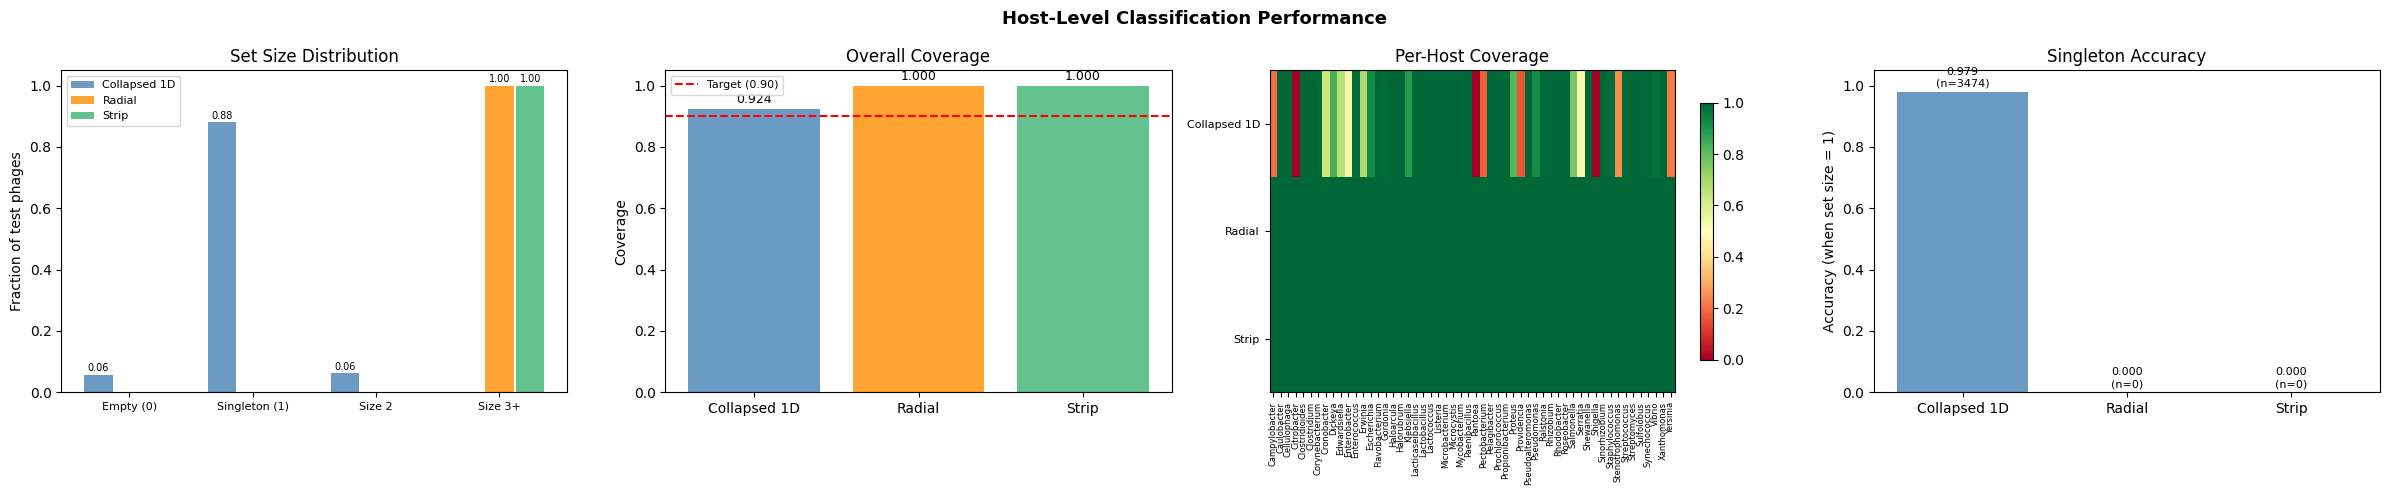

In [22]:
fig, axes = plt.subplots(1, 4, figsize=(24, 5))
colors  = ["steelblue", "darkorange", "mediumseagreen"]
offsets = [-0.25, 0.0, 0.25]

# Plot 1: Set size distribution (0, 1, 2, 3+)
ax = axes[0]
size_labels = ["Empty (0)", "Singleton (1)", "Size 2", "Size 3+"]
x = np.arange(len(size_labels))
for name, key, c, off in zip(methods_names, method_keys, colors, offsets):
    m = test_metrics[key]
    n_total = len(m["set_sizes"])
    fracs = [
        sum(1 for s in m["set_sizes"] if s == 0) / n_total,
        sum(1 for s in m["set_sizes"] if s == 1) / n_total,
        sum(1 for s in m["set_sizes"] if s == 2) / n_total,
        sum(1 for s in m["set_sizes"] if s >= 3) / n_total,
    ]
    bars = ax.bar(x + off, fracs, width=0.23, label=name, color=c, alpha=0.8)
    for rect, val in zip(bars, fracs):
        if val > 0.01:
            ax.text(rect.get_x() + rect.get_width()/2, val + 0.005,
                    f"{val:.2f}", ha="center", va="bottom", fontsize=7)
ax.set_xticks(x)
ax.set_xticklabels(size_labels, fontsize=8)
ax.set_title("Set Size Distribution")
ax.set_ylabel("Fraction of test phages")
ax.legend(fontsize=8)

# Plot 2: Overall coverage
ax = axes[1]
means = [test_metrics[k]["coverage"] for k in method_keys]
bars  = ax.bar(methods_names, means, color=colors, alpha=0.8)
ax.axhline(1 - alpha, color="red", linestyle="--", label=f"Target ({1-alpha:.2f})")
ax.set_ylim(0, 1.05)
ax.set_title("Overall Coverage")
ax.set_ylabel("Coverage")
ax.legend(fontsize=8)
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9)

# Plot 3: Per-host coverage heatmap
ax = axes[2]
cov_matrix = np.array([
    [test_metrics[key]["per_host_coverage"].get(h, 0) for h in sorted_hosts]
    for key in method_keys
])
im = ax.imshow(cov_matrix, aspect="auto", vmin=0, vmax=1, cmap="RdYlGn")
ax.set_xticks(range(len(sorted_hosts)))
ax.set_xticklabels(sorted_hosts, rotation=90, fontsize=6)
ax.set_yticks(range(len(method_keys)))
ax.set_yticklabels(methods_names, fontsize=8)
ax.set_title("Per-Host Coverage")
plt.colorbar(im, ax=ax, shrink=0.8)

# Plot 4: Singleton accuracy
ax = axes[3]
accuracies = [test_metrics[k]["singleton_accuracy"] or 0 for k in method_keys]
ns = [int(test_metrics[k]["singleton_rate"] * len(test_metrics[k]["set_sizes"])) for k in method_keys]
bars = ax.bar(methods_names, accuracies, color=colors, alpha=0.8)
ax.set_ylim(0, 1.05)
ax.set_title("Singleton Accuracy")
ax.set_ylabel("Accuracy (when set size = 1)")
for bar, val, n_s in zip(bars, accuracies, ns):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f"{val:.3f}\n(n={n_s})", ha="center", va="bottom", fontsize=8)

plt.suptitle("Host-Level Classification Performance", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("host_classification_results.png", dpi=150, bbox_inches="tight")

### SCore distributiom


True-host score distribution (test set):
  Mean: 0.774, Std: 0.142
  Phages with true-host score > 0.5: 95.4%
  Phages with true-host score < 0.2: 0.6%


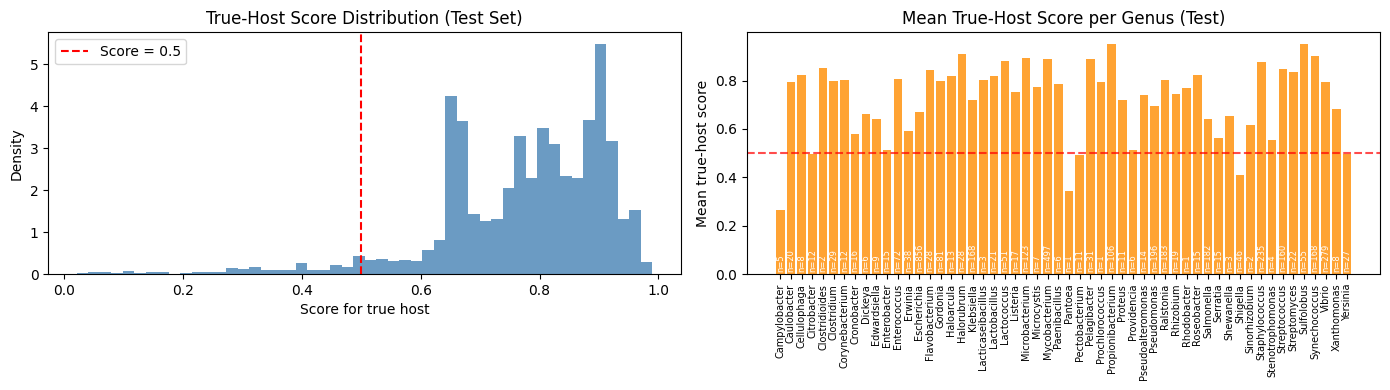

In [23]:
print("\nTrue-host score distribution (test set):")
true_host_scores = np.array([
    test_raw[i, sorted_hosts.index(test_labels[i])]
    for i in range(len(test_labels))
    if test_labels[i] in sorted_hosts
])
print(f"  Mean: {true_host_scores.mean():.3f}, Std: {true_host_scores.std():.3f}")
print(f"  Phages with true-host score > 0.5: {(true_host_scores > 0.5).mean()*100:.1f}%")
print(f"  Phages with true-host score < 0.2: {(true_host_scores < 0.2).mean()*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# True-host score histogram
ax = axes[0]
ax.hist(true_host_scores, bins=50, color="steelblue", alpha=0.8, density=True)
ax.axvline(0.5, color="red", linestyle="--", label="Score = 0.5")
ax.set_xlabel("Score for true host")
ax.set_ylabel("Density")
ax.set_title("True-Host Score Distribution (Test Set)")
ax.legend()

# Per-host mean true-host score
ax = axes[1]
host_means = []
host_ns = []
for h in sorted_hosts:
    mask = test_labels == h
    if mask.sum() == 0:
        host_means.append(0)
        host_ns.append(0)
        continue
    j = sorted_hosts.index(h)
    host_means.append(test_raw[mask, j].mean())
    host_ns.append(mask.sum())
bars = ax.bar(sorted_hosts, host_means, color="darkorange", alpha=0.8)
ax.axhline(0.5, color="red", linestyle="--", alpha=0.7)
ax.set_xticks(range(len(sorted_hosts)))
ax.set_xticklabels(sorted_hosts, rotation=90, fontsize=7)
ax.set_ylabel("Mean true-host score")
ax.set_title("Mean True-Host Score per Genus (Test)")
for bar, n in zip(bars, host_ns):
    ax.text(bar.get_x() + bar.get_width()/2, 0.01, f"n={n}", ha="center", va="bottom", fontsize=6, rotation=90, color="white" if n>0 else "black")

plt.tight_layout()
plt.savefig("host_score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()